In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install cartopy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install copernicusmarine

Note: you may need to restart the kernel to use updated packages.


# Offshore Wind Potential in the Baltic Sea

### Comparing the Energy Potential and Annual Production of Two Wind Farms in the Baltic Sea: Saare (Estonia) vs Baltyk I (Poland)

<center><img src="offshore.jpg" width="800"></center>

# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Libraries](#2.-Libraries)
- [3. Data](#3.-Data)
- [4. Wind Estimation and visualization](#4.-Wind-Estimation-and-visualization)
- [5. Wind Turbine Power Estimation](#5.-Wind-Turbine-Power-Estimation)
- [6. Evaluating Capacity and Output of Planned Wind Farms](#6.-Evaluating-Capacity-and-Output-of-Planned-Wind-Farms)
    - [6.1 Saare](#6.1-Saare)
    - [6.2 Baltyk I Phase I](#6.2-Baltyk-I-Phase-I) 
- [7. Investment Analysis and Economic Viability](#7.-Investment-Analysis-and-Economic-Viability)
    - [7.1 Parameters](#7.1-Parameters)
    - [7.2 Cost of project](#7.2-Cost-of-project)
    - [7.3 Degradation of offshore wind turbine](#7.3-Degradation-of-offshore-wind-turbine)
    - [7.4 Calculations](#7.4-Calculations)
- [8. Conclusion](#8.-Conclusion)

# 1. Introduction
[Go back to the "Table of contents"](#Table-of-contents)

Wind energy is one of the key sources of renewable power, offering a clean and sustainable alternative to fossil fuels. It helps reduce greenhouse gas emissions and contributes to energy security by diversifying the energy supply. Offshore wind, in particular, has high potential, as winds at sea are generally stronger and more consistent than on land. However, the amount of energy that can be generated depends heavily on local wind conditions, which are naturally variable and sometimes unpredictable. Understanding these conditions is essential for planning and evaluating the feasibility of wind energy projects.

<center><img src="example.png" width="800"></center>

The Baltic Sea was chosen for this study because it is less commonly analyzed compared to the most developed offshore wind regions in Europe, such as the United Kingdom, Germany, and the Netherlands. While these countries host the majority of offshore wind farms, the Baltic Sea offers a unique area where fewer studies exist, making it interesting to explore its wind energy potential. This selection allows for examining conditions that are not among the most obvious or well-studied, providing insight into how offshore wind farms might perform in a moderately developed and less familiar region.

The purpose of this study is to evaluate both the wind energy potential and the economic performance of offshore wind farms in the Baltic Sea. A full-year wind map for 2024 was analyzed to identify locations where wind farms are planned, rather than selecting only the best wind spots. Two representative sites were chosen for comparison: one with relatively higher wind potential and one with lower, to reflect realistic conditions. Using these sites, the study estimates expected energy production, costs, and long-term financial outcomes. This approach allows for an integrated assessment of where offshore wind farms could be viable and what factors most influence their performance.

# 2. Libraries
[Go back to the "Table of contents"](#Table-of-contents)

In [4]:
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import datetime
import pandas as pd
import os

#for modeling
from scipy.stats import linregress, pearsonr
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

#for animation
from PIL import Image 
from pathlib import Path
from IPython.display import display, HTML

# 3. Data
[Go back to the "Table of contents"](#Table-of-contents)

For this analysis, the **Copernicus Marine Service** will be used, specifically the dataset available at <a href="https://data.marine.copernicus.eu/product/WIND_GLO_PHY_L4_MY_012_006/description"> MyOcean Viwer</a>. This dataset provides various wind parameters on an hourly basis.

The primary area of interest is the Baltic Sea, and the main variables considered include `eastward_wind`, `northward_wind`, and `air_density`. For this study, the year 2024 was selected as the analysis period.

In [5]:
import copernicusmarine

copernicusmarine.subset(
  dataset_id="cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H",
  variables=["eastward_wind", "northward_wind", "air_density"],
  minimum_longitude=15.287654,
  maximum_longitude=30.328733,
  minimum_latitude=53.753365,
  maximum_latitude=66.082118,
  start_datetime="2024-01-01T14:04:00",
  end_datetime="2024-12-31T00:00:00",
)

INFO - 2026-02-22T22:47:33Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: ekalacheva
Copernicus Marine password: ········


INFO - 2026-02-22T22:47:44Z - Selected dataset version: "202211"
INFO - 2026-02-22T22:47:44Z - Selected dataset part: "default"
INFO - 2026-02-22T22:47:54Z - Starting download. Please wait...


  0%|          | 0/6249 [00:00<?, ?it/s]

INFO - 2026-02-22T22:54:00Z - Successfully downloaded to cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_15.31E-30.31E_53.81N-66.06N_2024-01-01-2024-12-31_(3).nc


ResponseSubset(file_path=WindowsPath('cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_15.31E-30.31E_53.81N-66.06N_2024-01-01-2024-12-31_(3).nc'), output_directory=WindowsPath('.'), filename='cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_15.31E-30.31E_53.81N-66.06N_2024-01-01-2024-12-31_(3).nc', file_size=599.8317061068702, data_transfer_size=5483.359511450381, variables=['eastward_wind', 'northward_wind', 'air_density'], coordinates_extent=[GeographicalExtent(minimum=15.3125, maximum=30.3125, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=53.8125, maximum=66.0625, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2024-01-01T15:00:00+00:00', maximum='2024-12-31T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [6]:
ds_w = xr.open_dataset('cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_15.31E-30.31E_53.81N-66.06N_2024-01-01-2024-12-31.nc')
ds_w

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 8746, latitude: 99, longitude: 121)
Coordinates:
  * latitude        (latitude) float32 396B 53.81 53.94 54.06 ... 65.94 66.06
  * longitude       (longitude) float32 484B 15.31 15.44 15.56 ... 30.19 30.31
  * time            (time) datetime64[ns] 70kB 2024-01-01T15:00:00 ... 2024-1...
Data variables:
    eastward_wind   (time, latitude, longitude) float64 838MB ...
    northward_wind  (time, latitude, longitude) float64 838MB ...
    air_density     (time, latitude, longitude) float64 838MB ...
Attributes:
    Conventions:               CF-1.6, ACDD-1.3
    references:                Copernicus Marine Service Product User Manual ...
    institution:               Royal Netherlands Meteorological Institute (KNMI)
    history:                   N/A
    title:                      Global Ocean - Wind and Stress - Hourly - Rep...
    copernicusmarine_version:  2.0.1

# 4. Wind Estimation and visualization
[Go back to the "Table of contents"](#Table-of-contents)

The wind is composed of two components: eastward *(u)* and northward *(v)*. Therefore, to calculate the total *wind speed*, the Pythagorean theorem is used:<br>
**wind speed** = $\sqrt{u²+v²}$

In [7]:
ds_w['wind_speed'] = np.sqrt(ds_w.eastward_wind*ds_w.eastward_wind + ds_w.northward_wind*ds_w.northward_wind)
ds_w

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 8746, latitude: 99, longitude: 121)
Coordinates:
  * latitude        (latitude) float32 396B 53.81 53.94 54.06 ... 65.94 66.06
  * longitude       (longitude) float32 484B 15.31 15.44 15.56 ... 30.19 30.31
  * time            (time) datetime64[ns] 70kB 2024-01-01T15:00:00 ... 2024-1...
Data variables:
    eastward_wind   (time, latitude, longitude) float64 838MB ...
    northward_wind  (time, latitude, longitude) float64 838MB ...
    air_density     (time, latitude, longitude) float64 838MB ...
    wind_speed      (time, latitude, longitude) float64 838MB 2.098 ... 6.305
Attributes:
    Conventions:               CF-1.6, ACDD-1.3
    references:                Copernicus Marine Service Product User Manual ...
    institution:               Royal Netherlands Meteorological Institute (KNMI)
    history:                   N/A
    title:                      Global Ocean - Wind and Stress - Hourly - Rep...
    copernicusmarine_version:  2.0.1

**The wind direction** is visualized using the `quiver` function, and **the wind speed** is visualized using `pcolor` from the Matplotlib library.

Text(0.5, 1.0, 'Wind Observations over the Baltic Sea : 2024-11-14T21:00:00')

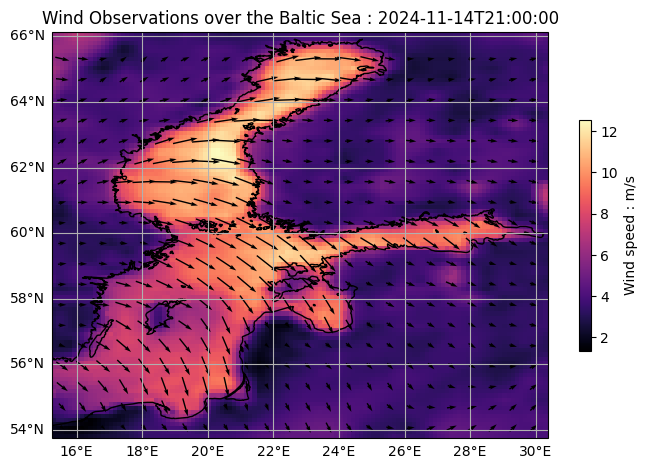

In [8]:
# draw a wind field

# coarsening the dataset to have bigger pixels and ease readibility.
ds_w_bis = ds_w.coarsen(latitude=5, longitude=5, boundary="trim").mean()

x = ds_w_bis.longitude.data
y = ds_w_bis.latitude.data

fig = plt.figure(figsize=(8,6))

# create an ax and select the projection of the map
ax = plt.axes(projection=ccrs.PlateCarree())                                       
ax.coastlines(color='k')
# add the longitude / latitude lines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
# remove latitude labels on the right
gl.right_labels = False                                                            
gl.top_labels = False 

t_plot = "2024-11-14T21:00:00"
date_plot = ds_w.sel(time=t_plot, method="nearest")
date_plot_bis = ds_w_bis.sel(time=t_plot, method="nearest")


## drawing background map of windspeed 
im = ax.pcolor(date_plot["longitude"], date_plot["latitude"], date_plot["wind_speed"], cmap="magma")
cbar = ax.figure.colorbar(im, ax=ax, label='Wind speed : m/s', shrink=0.5)

# drawing vector field
qv = ax.quiver(x, y, date_plot_bis["eastward_wind"], date_plot_bis["northward_wind"], pivot='mid', angles='xy')
# plt.quiverkey(qv, -70, 35, 2, 'wind speed', coordinates='data')

ax.set_title('Wind Observations over the Baltic Sea : %s'%t_plot)

The wind is animated over a specified period, for example, between 14 and 16 November 2024.

In [9]:
x = ds_w_bis.longitude.data
y = ds_w_bis.latitude.data

# starting time
tstart = np.datetime64('2024-11-14T21:00:00')

for c in range(48) :
    
    t_plot = tstart + np.timedelta64(c,'h')
    date_plot = ds_w.sel(time=t_plot, method="nearest")
    date_plot_bis = ds_w_bis.sel(time=t_plot, method="nearest")
    
    fig = plt.figure(figsize=(8,6))
    
    # create an ax and select the projection of the map
    ax = plt.axes(projection=ccrs.PlateCarree())                                       
    ax.coastlines(color='k')
    # add the longitude / latitude lines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    # remove latitude labels on the right
    gl.right_labels = False                                                            
    gl.top_labels = False 

    ## drawing background map of windspeed 
    im = ax.pcolor(date_plot["longitude"], date_plot["latitude"], date_plot["wind_speed"], cmap="magma", vmin=0, vmax=18)
    cbar = ax.figure.colorbar(im, ax=ax, label='Wind speed : m/s', shrink=0.5)

    # drawing vector field
    qv = ax.quiver(x, y, date_plot_bis["eastward_wind"], date_plot_bis["northward_wind"], pivot='mid', angles='xy')

    ax.set_title('Wind Observations over the Baltic Sea : %s'%t_plot)
    
    plt.tight_layout()
    t_plot_str = str(t_plot).replace(':', '')
    plt.savefig('out/wind_field_%s.png' % t_plot_str)
    plt.close()

In [11]:
# Search image files
image_path = Path('out/')
images = sorted(image_path.glob('wind_field_*.png'))

# Load the images
images_files = [Image.open(file) for file in images]

# Save as a GIF
images_files[0].save(
    'out/animated_wind_field.gif', 
    save_all=True, 
    append_images=images_files[1:], 
    duration=200,  # Duration between frames in milliseconds
    loop=10         
)

In [12]:
# Visualisation
display(HTML('<img src="out/animated_wind_field.gif" width="800"/>')) 

# 5. Wind Turbine Power Estimation
[Go back to the "Table of contents"](#Table-of-contents)

The available power is estimated using the dimensions of a typical offshore wind turbine, with 100-meter blades and a power coefficient of 0.45, using the following formula:

$P_{wt} = C_p\frac{1}{2}\rho Av^{3}$

Where:
*  $\rho$ is the air density
*  $A$ is the surface area covered by the rotors of the turbine
*  $v$ is the wind speed
*  $C_p$ is a performance coefficient. It accounts for the fact that a wind turbine does not convert all of the wind power to electricity. It generally between 0.4 and 0.5.

***Note***: Due to limitations in the ECMWF dataset, wind speed is available only at a height of 10 meters.
As wind data at the turbine hub height (~100 m) are not available, the estimated electrical power should be considered approximate, although ideally wind data at the turbine height would be used.

In [13]:
# computation of a new variable
Cp = 0.45
A = 100*100*np.pi

conv_power = 0.5*Cp*ds_w.air_density.data*A*(ds_w.wind_speed.data**3)
ds_w['conv_power'] = (('time', 'latitude', 'longitude'), conv_power)

The determination of the average power over the course of a year:

In [14]:
ds_w_avg = ds_w.mean(dim='time')

The map of the wind power potential by averaging the new power variable over an entire year:

Text(0.5, 1.0, 'Estimated available power over the Baltic Sea')

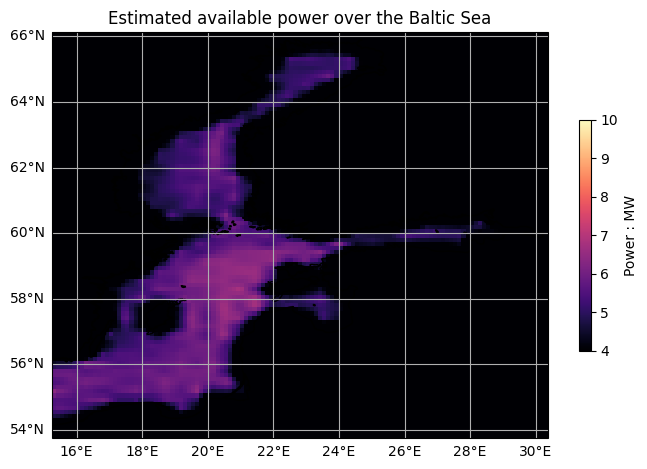

In [15]:
fig = plt.figure(figsize=(8,6))

ax = plt.axes(projection=ccrs.PlateCarree())                                       
ax.coastlines(color='k')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)                        
gl.right_labels = False                                                            
gl.top_labels = False 

im = ax.pcolor(ds_w_avg["longitude"], ds_w_avg["latitude"], ds_w_avg["conv_power"]*(10**-6), cmap="magma", vmin=4, vmax=10)
cbar = ax.figure.colorbar(im, ax=ax, label='Power : MW', shrink=0.5)
ax.set_title('Estimated available power over the Baltic Sea')

The estimated offshore wind power in the Baltic Sea is relatively low, generally ranging from 5 to 7 MW, indicating a moderate potential for wind energy development. 

The relatively low offshore wind power potential in the Baltic Sea is likely due to its semi-enclosed nature, which limits the development of strong winds compared to open ocean areas. As a result, overall wind speeds are moderate, reducing the maximum achievable power. The highest potential is generally observed near the coasts of Estonia and Latvia, although some isolated points with relatively higher power can also be found near the Polish coast.

Despite the moderate wind power potential in the Baltic Sea, several offshore wind farm projects are planned in the region. To illustrate and compare their performance, two projects are selected for analysis: one in Estonia, planned to have 100 turbines with a total capacity of 600 MW, and another in Poland, planned with 190 turbines and a total capacity of 1,140 MW. For these projects, we will estimate and compare the Capacity Factor, which measures the ratio of actual energy output to the maximum possible output.

<center><img src="123.jpg" width="800"></center>
Source of map: <a href="https://emodnet.ec.europa.eu/en/map-week-locations-wind-farms-0">EMODnet</a>

# 6. Evaluating Capacity and Output of Planned Wind Farms
[Go back to the "Table of contents"](#Table-of-contents)

To compute the extractable power from wind, we model a turbine’s output based on wind speed. A wind turbine operates in different phases depending on wind strength:
<ul>
    
**Below 3 m/s:** too weak to generate power.<br>

**3–12 m/s:** power increases with the cube of wind speed.<br>

**12–25 m/s:** nominal phase, producing rated power.<br>

**Above 25 m/s:** turbine is shut down for safety.<br>
</ul>

These thresholds are typical and may vary by turbine model *(some turbines can operate up to 30 m/s)*

This model is then applied to the wind speed time series to estimate actual power output.

In [16]:
# computation of real power for a wind turbine 

def power_curve(v, P_max, v_min, v_nominal, v_max):
    if v < v_min or v > v_max:
        return 0  # Wind turbine stopped
    elif v < v_nominal:
        return (v / v_nominal) ** 3 * P_max  # power increase
    else:
        return P_max  # Max power reached
    


def wind_farm(ds, lon, lat, model, nb_turbines):
    ds_point = ds.sel(longitude=lon, method='nearest').sel(latitude=lat, method='nearest')
    
    ds_point['power_output'] =  ('time', np.array([power_curve(v, model['P_max'], model['v_min'], model['v_nominal'], model['v_max']) for v in ds_point.wind_speed.data])*nb_turbines)
    ds_point['work_flag'] = ('time', np.where(ds_point.power_output.data > 0, 1, 0))
    ds_point['nominal_flag'] = ('time', np.where(ds_point.power_output.data == ds_point.power_output.data.max(), 1, 0))
    ds_point['partial_flag'] = ('time', np.where((ds_point.power_output.data < ds_point.power_output.data.max()) & (ds_point.power_output.data > 0), 1, 0))

    # energy timeseries
        
    return ds_point

Key characteristics of selected offshore wind farms:
| Characteristic              |Estonia Wind Farm|Poland Wind Farm |
|-----------------------------|-----------------|-----------------|
| **Name**                    | Saare           | Baltyk I Phase I|
| **Country**                 | Estonia         | Poland          |
| **Number of Turbines**      | 100             | 76              |
| **Capacity (MW)**           | 1400            | 1140            |
| **Latitude**                | 58° 8' 24"      | 55° 31' 12"     |
| **Longitude**               | 21° 40' 12"     | 17° 15' 36"     |
      

**Saare:** *According to the Environmental Impact Assessment(EIA) the planned total installed capacity of the wind farm is approximately 1400MW with 100 turbines. The specific turbine model has not yet been finalized, and individual turbine capacities are expected to range between 12 and 14 MW.*

**Baltyk I Phase I:** *All dates was taken from the Environmental Impact Assessment (EIA) document for this project and from the offical web page on of the developer of this project Northland Power*

In this cell, we define a hypothetical model for a wind turbine, using the wind threshold mentioned above and a typical nominal power according to our data.  

Next, we create a virtual wind farm at a designated location, with a chosen number of wind turbines. The power output of the farm will be displayed, along with the total amount of energy generated over a year.

In [17]:
# data of our virtual wind farm

# inputs

model_saare = {
    'v_min':3, 'v_nominal':12, 'v_max':25,   # typical thresholds in m/s
    'P_max':14  # nominal power in MW
}


model_poland = {
    'v_min':3, 'v_nominal':12, 'v_max':25,   # typical thresholds in m/s
    'P_max':15 # nominal power in MW
}

lon_saare = 21.40
lat_saare = 58.8
nb_turbines_saare = 100

lon_poland = 17.15
lat_poland = 55.31
nb_turbines_poland = 76
###  Dataset for the wind farm

ds_point_saare = wind_farm(ds_w, lon_saare, lat_saare, model_saare, nb_turbines_saare)
ds_point_poland = wind_farm(ds_w, lon_poland, lat_poland, model_poland, nb_turbines_poland)

To conclude, we can calculate the **capacity factor** of our wind farm models. It is simply the proportion of energy generated with respect to the theoretical maximum production.

$CF = \frac{E_{gen}}{E_{max}} = \frac{E_{gen}}{P_{max}x8760 h}$

In [18]:
CF_saare = (ds_point_saare.power_output.sum())/((model_saare["P_max"]*nb_turbines_saare)*8760)
CF_poland = (ds_point_poland.power_output.sum())/((model_poland["P_max"]*nb_turbines_poland)*8760)

Now, we will analyze the graph showing the results obtained for each of the wind farms

## 6.1 Saare
[Go back to the "Table of contents"](#Table-of-contents)

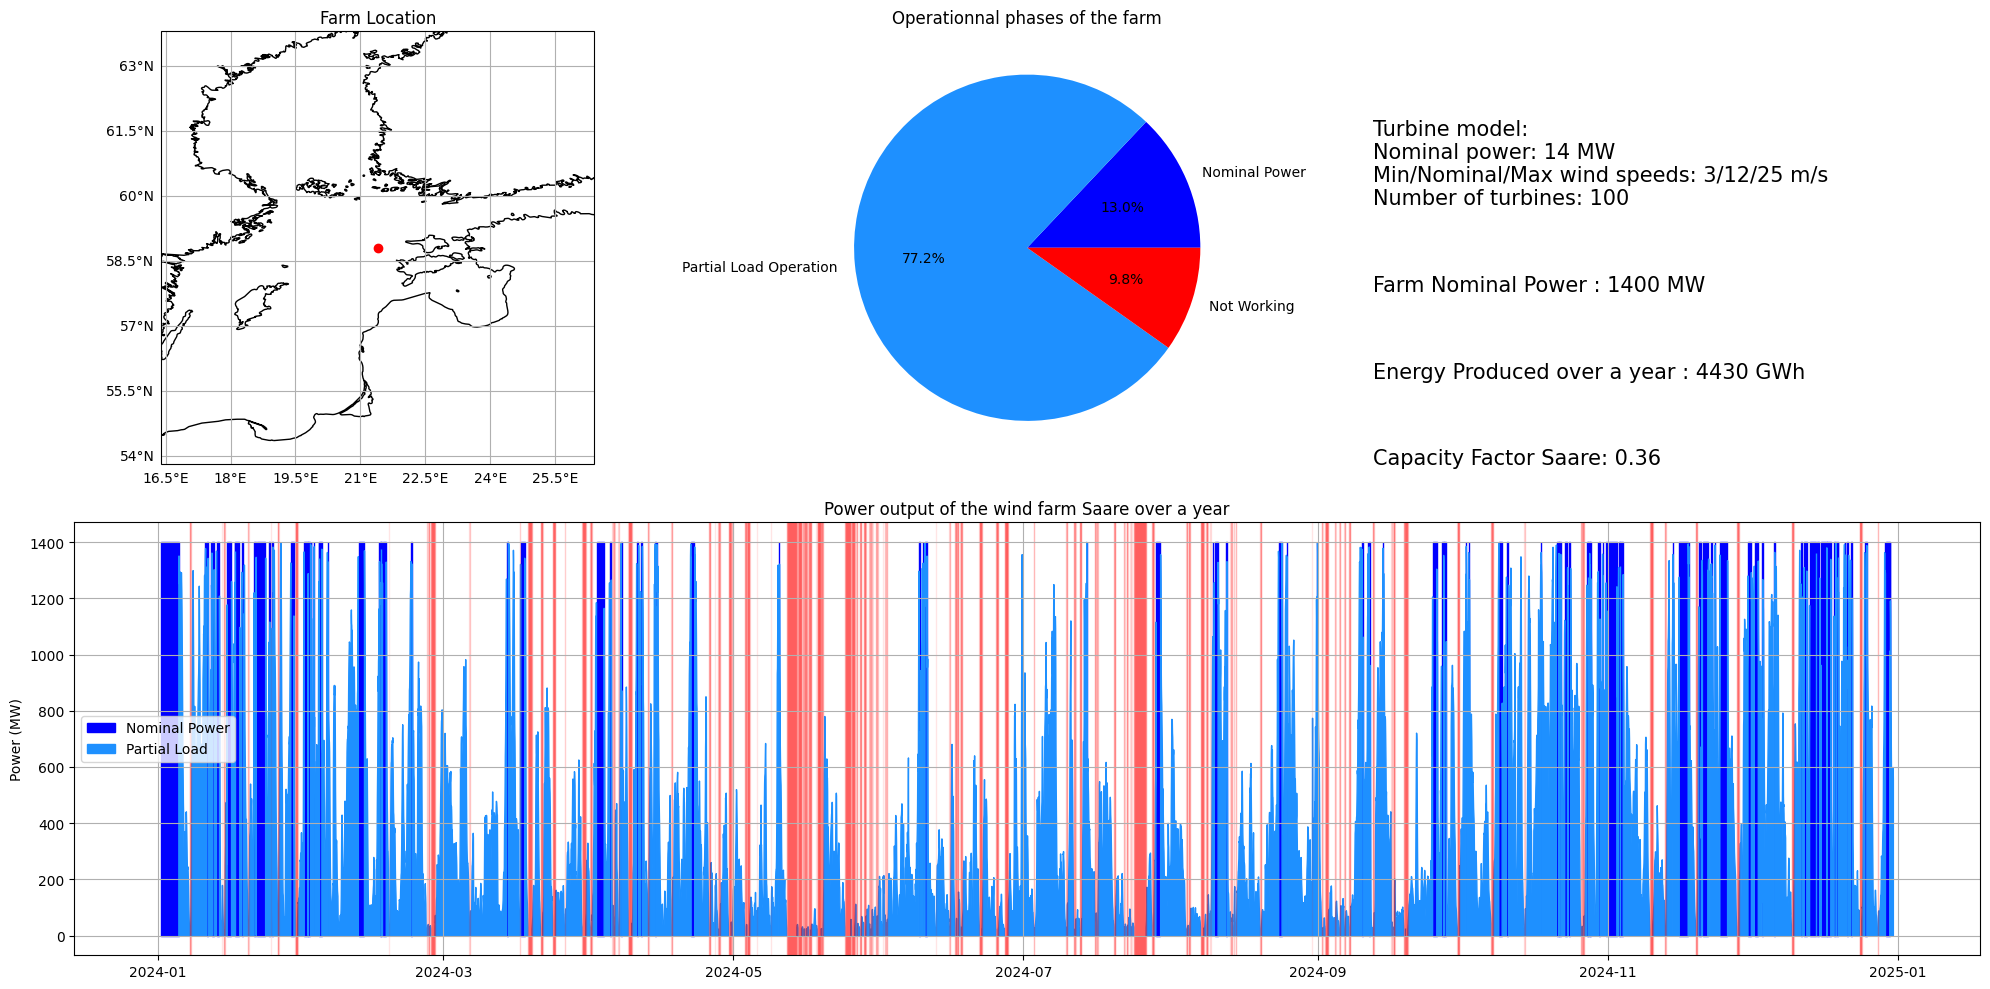

In [19]:
fig = plt.figure(figsize=(20,10))

ax1 = plt.subplot(231, projection=ccrs.PlateCarree())
ax1.coastlines(color='k')
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)                        # add the longitude / latitude lines
gl.right_labels = False                                                            # remove latitude labels on the right
gl.top_labels = False 

ax1.set_xlim(lon_saare-5, lon_saare+5)
ax1.set_ylim(lat_saare-5, lat_saare+5)

ax1.scatter([lon_saare], [lat_saare], c='r')
ax1.set_title('Farm Location')

# pie chart
ax2 = plt.subplot(232)

max_count = np.where(ds_point_saare.power_output.data == ds_point_saare.power_output.data.max(), 1, 0).sum()
incr_count = ds_point_saare.work_flag.sum() - max_count
false_count = len(ds_point_saare.work_flag.data) - ds_point_saare.work_flag.sum()

ax2.pie([ds_point_saare.nominal_flag.sum(), ds_point_saare.partial_flag.sum(), len(ds_point_saare.work_flag.data) - ds_point_saare.work_flag.sum()],
        labels=['Nominal Power', 'Partial Load Operation', 'Not Working'],
        colors=['blue', 'dodgerblue', 'red'],
        autopct='%1.1f%%')

ax2.set_title("Operationnal phases of the farm")

axt = plt.subplot(233)

axt.text(0,0.6, 'Turbine model:\nNominal power: %d MW\nMin/Nominal/Max wind speeds: %d/%d/%d m/s\nNumber of turbines: %d' % (model_saare['P_max'], model_saare['v_min'], model_saare['v_nominal'], model_saare['v_max'], nb_turbines_saare), fontsize=15)
axt.text(0,0.4, 'Farm Nominal Power : %d MW' % (model_saare["P_max"]*nb_turbines_saare), fontsize=15)
axt.text(0,0.2, 'Energy Produced over a year : %d GWh' % (ds_point_saare.power_output.sum()*0.001), fontsize=15)
axt.text(0,0, 'Capacity Factor Saare: %.2f' % (CF_saare), fontsize=15)

axt.set_axis_off()

ax3 = plt.subplot(212)

#ax3.plot(ds_point.time, ds_point.power_output, linewidth=0.5, color='dodgerblue')

max_out = np.where(ds_point_saare.nominal_flag.data==True, ds_point_saare.power_output.data, np.nan)
partial_out = np.where(ds_point_saare.partial_flag.data==True, ds_point_saare.power_output.data, np.nan)

ax3.fill_between(ds_point_saare.time, max_out, interpolate=True, color='blue', label='Nominal Power')
ax3.fill_between(ds_point_saare.time, partial_out, interpolate=True, color='dodgerblue', label='Partial Load')
for i in range(len(ds_point_saare.time.data)):
    if not ds_point_saare.work_flag.data[i]:
        ax3.axvspan(ds_point_saare.time.data[i], ds_point_saare.time.data[i+1], color='red', alpha = 0.1)

ax3.set_title('Power output of the wind farm Saare over a year')
ax3.set_ylabel('Power (MW)')
ax3.grid(True)
ax3.legend()

plt.tight_layout()

<p style='text-indent: 30px'>Based on wind data from 2024, if this wind farm were already constructed and operational, it could generate approximately <b>4,430 GWh per year</b>. </p>
<p style='text-indent: 30px'>The farm <b>does not operate 9.8% of the time</b>, reaches nominal power 13% of the time, and operates at partial load for the remaining period. The periods when the farm is mostly not operational fall in the spring and summer months, especially noticeable in June and August, with some isolated non-operational days throughout the year. Most days at nominal power occur between November and March. </p>
<p style='text-indent: 30px'>The annual energy produced could supply electricity equal to approximately <b>54% of Estonia's total electricty consumption</b>, based on Estonia's annual electricity demand of about 8.26 TWh in 2024 as reported by the national grid operator. </p>
<p style='text-indent: 30px'><i>The capacity factor</i> is 36%, which is slightly below the typical range of 40–55%, but still within the technically feasible range for the Baltic Sea region. </p> 
<p style='text-indent: 30px'>It should be noted that the project estimates that this wind farm could generate over 6 TWh per year, which seems overly optimistic. Moreover, these calculations are based on wind speeds at 10 meters above sea level, rather than the actual turbine hub height of approximately 100 meters, where wind speeds would likely be higher. </p>
<p style='text-indent: 30px'>Finally, wind is inherently variable, so annual generation will fluctuate, and the 4.43 TWh figure should be considered an average based on 2024 conditions.</p>

Currently, the project timeline is as follows:
<center><img src="saare.png" width="800"></center>
Source of map: <a href="https://swe.ee/">Saare Wind Energy</a>

## 6.2 Baltyk I Phase I
[Go back to the "Table of contents"](#Table-of-contents)

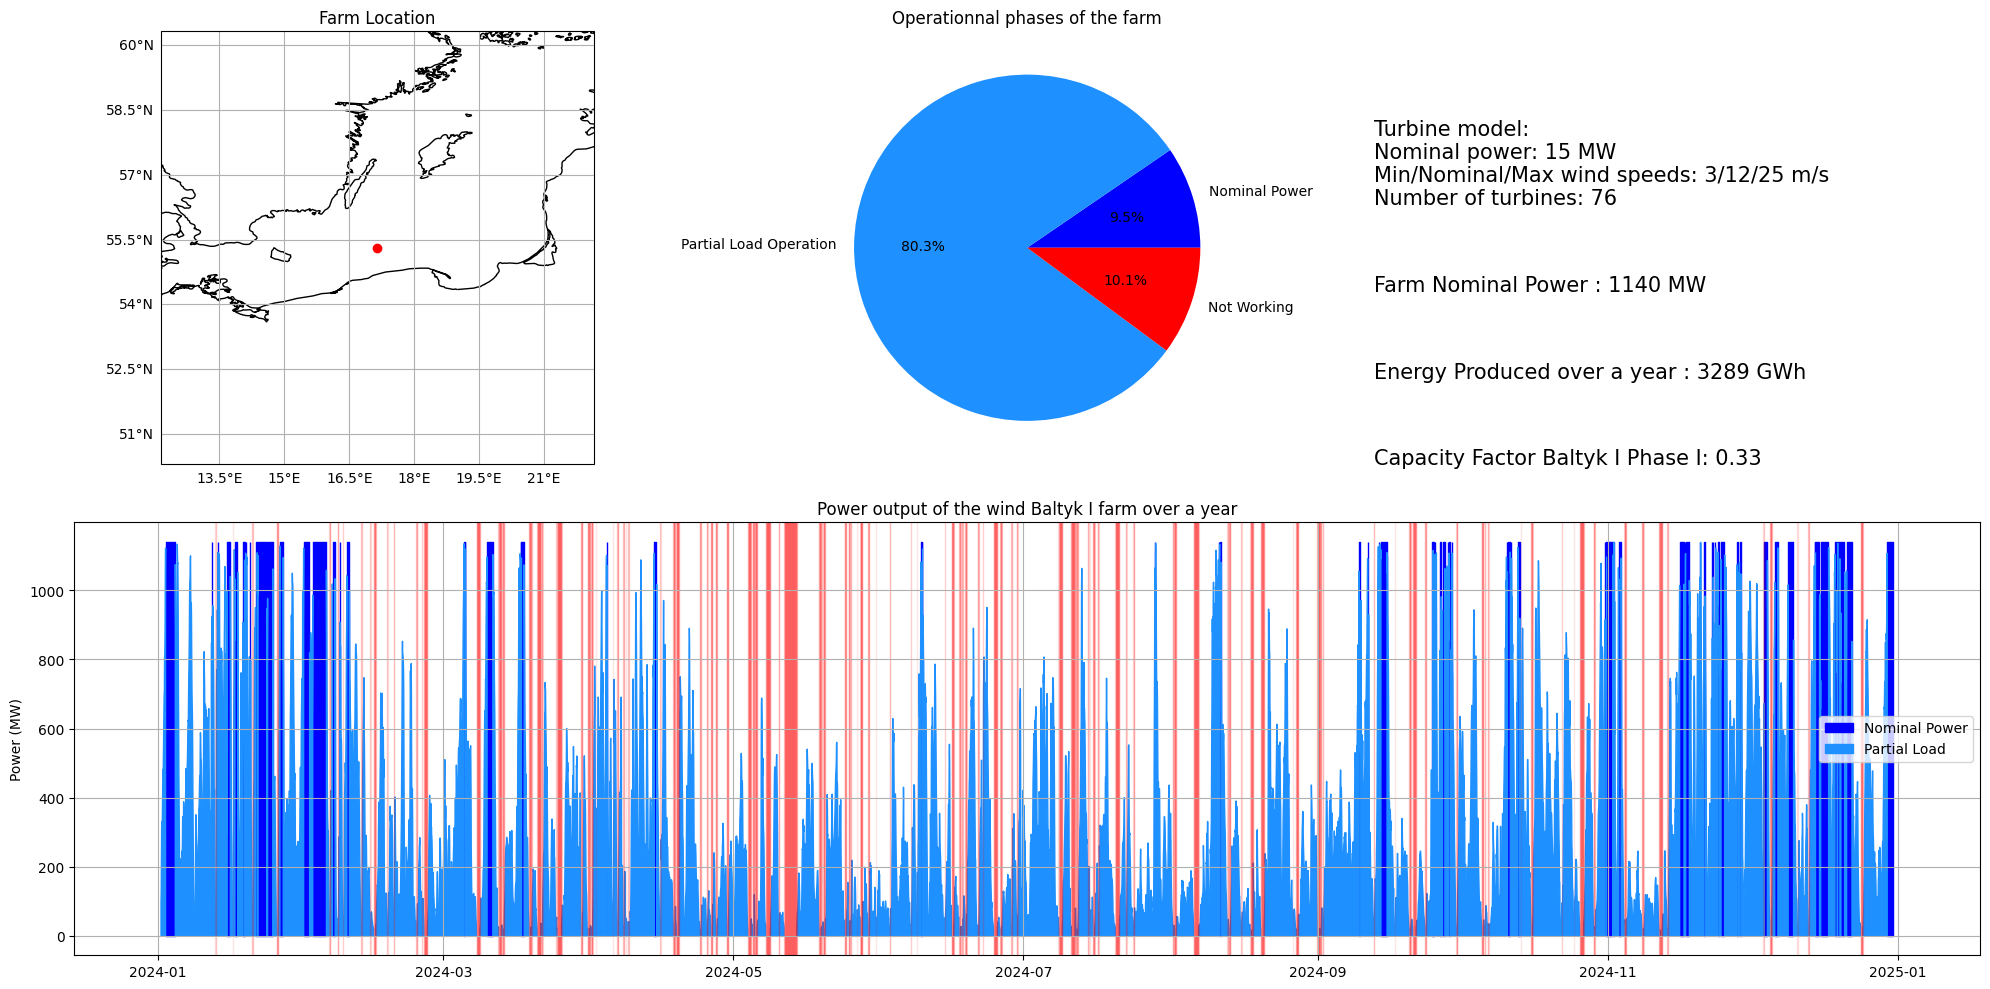

In [20]:
fig = plt.figure(figsize=(20,10))

ax1 = plt.subplot(231, projection=ccrs.PlateCarree())
ax1.coastlines(color='k')
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)                        # add the longitude / latitude lines
gl.right_labels = False                                                            # remove latitude labels on the right
gl.top_labels = False 

ax1.set_xlim(lon_poland-5, lon_poland+5)
ax1.set_ylim(lat_poland-5, lat_poland+5)

ax1.scatter([lon_poland], [lat_poland], c='r')
ax1.set_title('Farm Location')

# pie chart
ax2 = plt.subplot(232)

max_count = np.where(ds_point_poland.power_output.data == ds_point_poland.power_output.data.max(), 1, 0).sum()
incr_count = ds_point_poland.work_flag.sum() - max_count
false_count = len(ds_point_poland.work_flag.data) - ds_point_poland.work_flag.sum()

ax2.pie([ds_point_poland.nominal_flag.sum(), ds_point_poland.partial_flag.sum(), len(ds_point_poland.work_flag.data) - ds_point_poland.work_flag.sum()],
        labels=['Nominal Power', 'Partial Load Operation', 'Not Working'],
        colors=['blue', 'dodgerblue', 'red'],
        autopct='%1.1f%%')

ax2.set_title("Operationnal phases of the farm")

axt = plt.subplot(233)

axt.text(0,0.6, 'Turbine model:\nNominal power: %d MW\nMin/Nominal/Max wind speeds: %d/%d/%d m/s\nNumber of turbines: %d' % (model_poland['P_max'], model_poland['v_min'], model_poland['v_nominal'], model_poland['v_max'], nb_turbines_poland), fontsize=15)
axt.text(0,0.4, 'Farm Nominal Power : %d MW' % (model_poland["P_max"]*nb_turbines_poland), fontsize=15)
axt.text(0,0.2, 'Energy Produced over a year : %d GWh' % (ds_point_poland.power_output.sum()*0.001), fontsize=15)
axt.text(0,0, 'Capacity Factor Baltyk I Phase I: %.2f' % (CF_poland), fontsize=15)
axt.set_axis_off()

ax3 = plt.subplot(212)

#ax3.plot(ds_point.time, ds_point.power_output, linewidth=0.5, color='dodgerblue')

max_out = np.where(ds_point_poland.nominal_flag.data==True, ds_point_poland.power_output.data, np.nan)
partial_out = np.where(ds_point_poland.partial_flag.data==True, ds_point_poland.power_output.data, np.nan)

ax3.fill_between(ds_point_poland.time, max_out, interpolate=True, color='blue', label='Nominal Power')
ax3.fill_between(ds_point_poland.time, partial_out, interpolate=True, color='dodgerblue', label='Partial Load')
for i in range(len(ds_point_poland.time.data)):
    if not ds_point_poland.work_flag.data[i]:
        ax3.axvspan(ds_point_poland.time.data[i], ds_point_poland.time.data[i+1], color='red', alpha = 0.1)

ax3.set_title('Power output of the wind Baltyk I farm over a year')
ax3.set_ylabel('Power (MW)')
ax3.grid(True)
ax3.legend()

plt.tight_layout()

<p style='text-indent: 30px'>Based on 2024 wind data, the farm is expected to generate approximately <b>3,289 GWh over the year</b>.</p>
<p style='text-indent: 30px'>During operation, about <b>10% of the time the turbines will not produce electricity</b> due to suboptimal wind conditions, 9.5% of the time they will operate at nominal power, and the remaining 80% at partial load. Zero-production days are concentrated between March and September, while peak output occurs from December to February. </p>
<p style='text-indent: 30px'><i>The estimated capacity factor</i> of the Baltic offshore wind farm is approximately 33%, which is slightly lower than that of the Estonian project, this value is typical for offshore wind conditions in the Baltic Sea region given its geographical and wind characteristics.</p>
<p style='text-indent: 30px'>Baltic Power claims the farm could cover ~3% of Poland's annual demand; our calculated output of 3.3–3.4 TWh aligns reasonably well with these official estimates.</p>

***Note:*** It should be noted that days with zero production are due to wind conditions, not turbine failures or maintenance. In reality, not all turbines will be operational at all times, as some may be temporarily offline for maintenance or repairs. Wind, as a highly variable parameter, cannot be precisely forecasted; annual generation will fluctuate depending on wind patterns, with some periods experiencing stronger or weaker winds.

# 7. Investment Analysis and Economic Viability
[Go back to the "Table of contents"](#Table-of-contents)

To assess the feasibility of offshore wind farms, capacity factors and energy yields alone are insufficient. A comprehensive economic evaluation is required to estimate profitability against capital investments. This analysis calculates the payback period while accounting for the ~25-year operational lifespan of turbines, including ongoing costs for maintenance, repairs, and technical risks.

## 7.1 Parameters
[Go back to the "Table of contents"](#Table-of-contents)

**The Contract for Difference** is a mechanism that guarantees a fixed electricity price over the 25-year operational period. The government compensates the producer if market prices fall below the strike price, and the producer returns the surplus if prices exceed it. For this model, a constant price is assumed due to the lack of long-term market volatility forecasts.

**Operational expenditure (OPEX)** represents the recurring costs of maintaining and operating the wind farm. This includes preventive/corrective maintenance, offshore logistics, vessel charters, insurance, and remote diagnostics.

<p style='text-indent: 30px'><i><b>Note:</b> OPEX is not publicly disclosed in detail and remains uncertain; industry estimates suggest it can account for up to 40% of total lifecycle costs.</i></p>

**Levelized cost of electricity (LCOE)** is the average cost of producing 1 MWh of electricity over the project's entire lifetime, used to compare the cost-effectiveness of different energy sources.

**Net Present Value (NPV)** is the total projected profit of the project over its lifetime, calculated by subtracting initial investments, operating costs, and taxes from the discounted future revenues.

## 7.2 Cost of project
[Go back to the "Table of contents"](#Table-of-contents)

<ul>
<li><i>Saare</i><br>
According to the European Commission (January 2026), the total cost of the offshore wind farm is estimated at <b>€4.3 billion</b> (this figure <b><i>is provisional</i></b> and may increase significantly depending on material costs and other economic factors at the start of construction). Several EU grants have already been provided, including €25 million for pre-construction studies, €10 million for early-stage activities, and an €80 million tender for further energy studies. It is important to note that these grants cover only preparatory work and do not reduce the total investment required for construction. The project timeline runs from initial feasibility studies (pre-2023) to commissioning in 2033, with <b>construction scheduled between 2027 and 2033</b></li>

<li><i>Baltyk I </i><br>
    The data for this project is sourced directly from <a href="https://www.northlandpower.com/en/news/northland-power-announces-signing-of-credit-agreement-for-52-billion-project-financing-at-baltic-pow.aspx">Northland Power</a>, one of the project’s lead developers. Unlike the Estonian project, the construction expenses for Baltyk I have already been calculated and reported. The analysis incorporates these finalized costs along with the specific CfD price, interest rates, and other financial parameters provided in the company’s official reports.</li>
    
</ul>

## 7.3 Degradation of offshore wind turbine
[Go back to the "Table of contents"](#Table-of-contents)

*A critical factor in this model is the annual efficiency degradation. Based on studies of Northern European wind farms (Olauson et al., 2017), factors such as ice accretion and humidity can significantly reduce capacity. For this analysis, a **0.7% annual degradation rate is assumed**. This reflects a realistic midpoint between reported international benchmarks (0.53% in the US and up to 0.87% in the UK) and accounts for the harsh conditions of the Baltic Sea. While the Baltic has lower salinity compared to the open ocean, its cold climate and high humidity lead to significant ice accretion, which poses a unique challenge for turbine performance. It should be noted that these rates vary significantly depending on the specific environmental and marine conditions to which the turbines are exposed*

## 7.4 Calculations
[Go back to the "Table of contents"](#Table-of-contents)

The CfD scheme in Estonia is based on the average wholesale electricity price for 2024, whereas in Poland it is determined by a project-specific strike price, with the contract covering the entire duration of each long-term project.

Since wind generation is inherently unpredictable, the CfD provides the price certainty required for investment. Relying on market prices for long-term evaluation is not feasible, as they are driven by volatile geopolitical and economic factors. Therefore, we use the CfD as the reference price per MWh to assess the true economic viability of both projects.

For this calculation, the <a href="https://www.sse.com/media/xi2kjqwc/economic-analysis-of-strathy-north-wind-farm.pdf">Strathy North Wind Farm</a> was used as a reference, as both its the total investment and OPEX were available. The annual OPEX for the projects was estimated as a percentage of total investment. According to industry reports, cumulative OPEX over 20 years can amount to roughly 50% of the initial investment. This aligns with data from <a href="https://ixrenewables.com/en/services/opex-optimization">IX Renewables</a>, which indicates that operating expenses account for up to 40% of a wind farm's total life cycle costs. For this model, it is assumed that major OPEX payments begin in year 5 of the project.

In [21]:
data = {
    "Parameter":[
        "Energy_Mwh/year",
        "CfD_$/Mwh",
        "Total_cost_$",
        "Tax"
    ],
    "Estonia":[
        4430000,
        88.85, 
        4644000000,
        0
    ],
    "Poland":[
        3289000,
        85.2, 
        4810000000,
        0.19
    ]
}

df = pd.DataFrame(data)
df.set_index("Parameter", inplace = True)
years = 25
inflation = 0.022
opex_percentage = 0.0245
opex_years = 20
wear_rate = 0.007
d = 0.05 #the decrease in the value of money over time
df

,Estonia,Poland
Parameter,,
Energy_Mwh/year,4.430000e+06,3.289000e+06
CfD_$/Mwh,8.885000e+01,8.520000e+01
Total_cost_$,4.644000e+09,4.810000e+09
Tax,0.000000e+00,1.900000e-01


In [22]:
df =df.T
df

Parameter,Energy_Mwh/year,CfD_$/Mwh,Total_cost_$,Tax
Estonia,4430000.0,88.85,4.644000e+09,0.00
Poland,3289000.0,85.20,4.810000e+09,0.19


A geometric progression was used to calculate total OPEX and net revenue over the 25-year project lifespan. This approach accounts for the compounding effects of inflation, the discount rate, and a 0.7% annual turbine degradation rate, which reflects the harsh operating conditions of the Baltic Sea.

In [23]:
def total_25(n0, r, years):
    q = ((1 + inflation)*(1 - wear_rate))/(1 + d)
    total_profit = n0 * (1 - q**years)/(1 - q)
    return total_profit

df['Annual_Gross_Revenue'] = df['Energy_Mwh/year'] * df['CfD_$/Mwh']
df['opex_annual'] = df['Total_cost_$'] * opex_percentage

In [24]:
df['Revenue_inflated_25'] = total_25(df['Annual_Gross_Revenue'], inflation, years)

In [25]:
def total_opex_25(n0, r, years):
    q = ((1 + inflation)*(1 + wear_rate))/(1 + d)
    total_profit = n0 * (1 - q**years)/(1 - q)
    return total_profit

df['Opex_cost_lifetime'] = total_opex_25(df['opex_annual'], inflation, opex_years)

The next step is to calculate the net profit by deducting total OPEX and applicable taxes from the gross revenue.

In [26]:
df['Net_Profit_before_Tax'] = df['Revenue_inflated_25'] - df['Opex_cost_lifetime']
df['Net_Profit_after_Tax'] = df['Net_Profit_before_Tax'] * (1-(df['Tax']))
df

Parameter,Energy_Mwh/year,CfD_$/Mwh,Total_cost_$,Tax,Annual_Gross_Revenue,opex_annual,Revenue_inflated_25,Opex_cost_lifetime,Net_Profit_before_Tax,Net_Profit_after_Tax
Estonia,4430000.0,88.85,4.644000e+09,0.00,393605500.0,113778000.0,6.738250e+09,1.893446e+09,4.844804e+09,4.844804e+09
Poland,3289000.0,85.20,4.810000e+09,0.19,280222800.0,117845000.0,4.797218e+09,1.961127e+09,2.836090e+09,2.297233e+09


Profitability and Payback

In [27]:
#Average net revenue after tax
df['Avg_NPAT_per_year'] = df['Net_Profit_after_Tax']/25

#NPV
df['NPV'] = df['Net_Profit_after_Tax'] - df['Total_cost_$']

#LCOE 
q_energy = 1 - wear_rate
df['Energy_lifetime_real'] = df['Energy_Mwh/year'] * (1 - q_energy**years) / (1 - q_energy)
df['LCOE'] = (df['Opex_cost_lifetime'] + df['Total_cost_$'])/(df['Energy_lifetime_real'])

# Return on Investment
df['ROI'] = ((df['Net_Profit_after_Tax'] - df['Total_cost_$'])/df['Total_cost_$']) * 100

#Profitability Index
df['RI'] = df['Net_Profit_after_Tax']/df['Total_cost_$']

df['Payback'] = df['Total_cost_$']/df['Avg_NPAT_per_year']

df

Parameter,Energy_Mwh/year,CfD_$/Mwh,Total_cost_$,Tax,Annual_Gross_Revenue,opex_annual,Revenue_inflated_25,Opex_cost_lifetime,Net_Profit_before_Tax,Net_Profit_after_Tax,Avg_NPAT_per_year,NPV,Energy_lifetime_real,LCOE,ROI,RI,Payback
Estonia,4430000.0,88.85,4.644000e+09,0.00,393605500.0,113778000.0,6.738250e+09,1.893446e+09,4.844804e+09,4.844804e+09,1.937921e+08,2.008036e+08,1.019276e+08,64.138139,4.323937,1.043239,23.963820
Poland,3289000.0,85.20,4.810000e+09,0.19,280222800.0,117845000.0,4.797218e+09,1.961127e+09,2.836090e+09,2.297233e+09,9.188932e+07,-2.512767e+09,7.567491e+07,89.476518,-52.240478,0.477595,52.345583


The Polish project has a payback period of 52 years and an LCOE higher than the selling price, even before tax, making it unprofitable under current assumptions. In contrast, the Estonian project has a payback period of 24 years and a positive LCOE, and its better performance is supported by zero taxes and relatively low investment per unit of capacity.

Comparing the ROI and RI between the two projects, Estonia shows a positive ROI and an RI above 1, indicating that the investment is profitable and adds value. Poland, on the other hand, has a negative ROI and an RI below 1, meaning the project is not economically attractive under the current conditions.

Overall, the high plant energy generation in Estonia due to more turbines in favorable wind conditions, combined with relatively low investment per unit of capacity, makes the Estonian project more attractive financially, although results may vary depending on future changes in costs, prices, and wind conditions.

The results are based on averaged assumptions for inflation, discount rate, degradation, and annual energy production. In reality, all of these factors will vary over time, and actual wind conditions may differ from the assumed constant annual generation. Investment costs, especially for the Estonian project which is not yet built, may increase, which would directly affect profitability. Electricity prices may also change, potentially improving or worsening the financial outlook, particularly for Poland. Therefore, the results should be seen as indicative estimates rather than precise forecasts, showing the general economic tendency under the selected assumptions

## 8. Conclusion
[Go back to the "Table of contents"](#Table-of-contents)

The results are based on average assumptions for inflation, discount rate, degradation, and annual energy production. In reality, all of these factors can vary over time, and wind conditions may be better or worse than assumed. Investment costs, especially for the Estonian project which hasn’t been built yet, could rise, affecting profitability. The Polish project has already been constructed by two private energy companies and represents only the first phase of a larger multi-phase development, so even if the first phase appears marginal, it is likely profitable overall. Therefore, these results should be seen as rough estimates showing the general economic tendency, not exact predictions.

*This analysis was conducted simply to estimate how much energy could realistically be generated in a given sea area under the proposed wind conditions. In contrast, project developers often claim higher energy outputs in promotional materials than would actually be achievable in practice.*